# Classification
### Jimmy Azar

Under the probabilistic approach to classification, an object $x$ is classified as belonging to class $\omega_i$ with the highest posterior probability $p(\omega_i|x)$. For the majority of classifiers that follow this approach, the posterior probability is derived using the class-conditional density $p(x|\omega_i)$ in conjunction with Bayes' theorem. However, one classifier that is an exception to this rule is the logistic classifier. Although its classification decision is still based on the maximum posterior probability, the logistic classifier attempts to directly model the posterior distributions without first estimating the class-conditional densities.

## The Logistic Classifier

In a binary classification problem with classes $\omega_1$ and $\omega_2$, the logistic classifier assumes the following:

$$ln \left( \dfrac{p(\textbf{x}|\omega_1 )}{p(\textbf{x}|\omega_2)} \right) = \textbf{w}_0 + \textbf{w}^T \textbf{x}$$

Using the above equation, we can derive the explicit form of the posterior probabilities which will be sigmoidal.

We load the data from the file 'gaussian2D.txt' to access a labeled two-class Gaussian dataset. Then, we build a logistic classifier using maximum likelihood estimation. We find the predicted labels over the same dataset, generate a confusion matrix, and compute the apparent error (i.e. as measured over the training set).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

path_to_file = '../data/gaussian2D.txt'
data = pd.read_csv(path_to_file, sep=' ')

X = data.iloc[:,:-1]
y = data.iloc[:,-1]

model = LogisticRegression(solver='lbfgs').fit(X, y)
y_pred = model.predict(X)
confusion_matrix(y_true=y, y_pred=y_pred)

array([[50,  0],
       [ 0, 50]])

We obtain a linear classifier with zero classification error over this simple dataset. Additionally, we plot one of the posterior distributions superimposed over a scatter plot of the data.

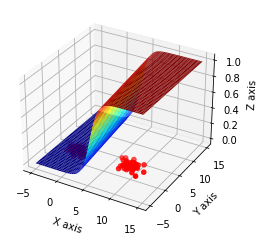

In [2]:
w_0 = model.intercept_
w = model.coef_

x1 = np.linspace(-5,15,200)
x2 = np.linspace(-5,15,200)
x, y = np.meshgrid(x1, x2)

z = [[np.exp(w_0 + w.dot([i,j]))[0] / (1 + np.exp(w_0 + w.dot([i,j])))[0] for i in x1] for j in x2]
z = np.array(z)
 
ax = plt.axes(projection='3d')
ax.plot_surface(x,y,z,cmap='jet')
ax.scatter(X['f1'], X['f2'], np.zeros(X.shape[0])+0.1, c='red')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

## Basics of Classification
### Normal-based Discriminants

Following the probabilistic approach to classification, if the conditional density function is known, everything about the classification problem is known, and an optimal decision may be reached resulting in the lowest possible error in the theoretical case: Bayes' error. However, since in practice we need to estimate the class conditional densities, the final classification rate will depend on how accurate our estimate really is. Density estimation is not a trivial task. Some methods assume a Gaussian model for the class densities, whereas others may use the mixture of Gaussians method or make use of Parzen density estimation or k-nearest neighbor density estimation. In the following exercise, we'll model the class density functions with a Gaussian model. Under the probabilistic approach to classification, the fundamental principles for solving any classification problem involve the following steps:

- Split your dataset into a training set and a test set.
- Estimate the class conditional probability density function for every class using the training set.
- For every object in the test set, compute the class conditional density.
- For every object in the test set, compute the posterior probability using Bayes' theorem.
- Assign every test object to the class with the highest posterior probability. The object will carry the 
  corresponding class label.

We load the data from the file 'trainfile.txt' and 'testfile.txt' to obtain labeled training and test sets respectively. Then, we create a 2D scatter plot using the training set.

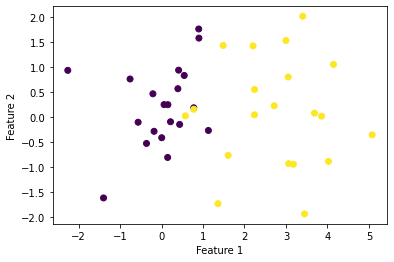

In [3]:
path_to_trainfile = '../data/trainfile.txt'
path_to_testfile = '../data/testfile.txt'

a = pd.read_csv(path_to_trainfile, sep=' ', header=None)
b = pd.read_csv(path_to_testfile, sep=' ', header=None)

X_train, y_train = a.iloc[:,:-1], a.iloc[:,-1]
X_test, y_test = b.iloc[:,:-1], b.iloc[:,-1]

plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Next, we divide the training set into two sets according to the class labels. Then, we estimate the probability density function for each class separately using a multivariate Gaussian. To do this, we begin by computing the mean and covariance matrices: m1, m2, S1, S2.

Then, we compute the conditional probability density function for the test objects.

In [4]:
m1 = X_train.loc[y_train==1].mean() 
m2 = X_train.loc[y_train==2].mean()

S1 = np.cov(X_train.loc[y_train==1], rowvar=False)
S2 = np.cov(X_train.loc[y_train==2], rowvar=False)

n_obj, n_dim = X_test.shape

X_test_bar1 = X_test - np.tile(m1,(n_obj,1))
X_test_bar2 = X_test - np.tile(m2,(n_obj,1))

prob1 = 1/np.sqrt((2*np.pi)**n_dim*np.linalg.det(S1)) * \
        np.diag(np.exp(-0.5*(X_test_bar1).dot(np.linalg.inv(S1)).dot(X_test_bar1.T)))
prob2 = 1/np.sqrt((2*np.pi)**n_dim*np.linalg.det(S2)) * \
        np.diag(np.exp(-0.5*(X_test_bar2).dot(np.linalg.inv(S2)).dot(X_test_bar2.T)))

We set the class prior probabilities to 1/2 and use Bayes' theorem to evaulate the posterior probabilities for the test objects. Then, we group the posterior probabilities into a 2D array and check that the sum of each row is 1 as it should be.

In [5]:
prior1, prior2 = 0.5, 0.5
px = prob1*prior1 + prob2*prior2

posterior1 = prob1*prior1/px
posterior2 = prob2*prior2/px
posterior = np.stack([posterior1,posterior2], axis=1)

posterior.sum(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Finally, we find the class with the highest posterior probability for each object. This way, every object receives a class label (either a 1 or 2). We've just constructed your own simple classifier. To evaluate the performance of the classifier, we compare the correct class labels of the test objects `y_test` with the ones returned by the classifier.

In [6]:
y_pred = 1 + posterior.argmax(axis=1)
print(y_pred)

n_error = (y_test!=y_pred).sum()
confusion_matrix(y_true=y_test, y_pred=y_pred)

[1 1 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 2 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2]


array([[45,  5],
       [ 3, 47]])

The quadratic discriminant function may be written as:

$$f(\textbf{x}) = \textbf{x}^T \textbf{W} \textbf{x} + \textbf{w}^T \textbf{x} + w_0$$

Using the same dataset as before, we now construct a quadratic classifier.

In [7]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as qda

model = qda().fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix(y_true=y_test, y_pred=y_pred)

array([[45,  5],
       [ 3, 47]])

Since our dataset is two-dimensional, we can visualize the decision boundary.

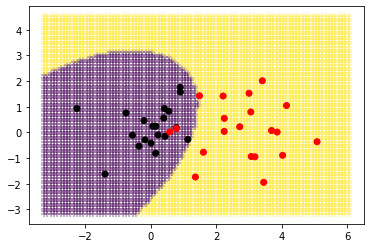

In [8]:
# decision boundary 
X = pd.concat([X_train, X_test]) # full dataset to derive axes limits

step = 0.1
x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min,x_max,step), np.arange(y_min,y_max,step))

labels_pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = labels_pred.reshape(xx.shape)

plt.scatter(xx.ravel(), yy.ravel(), c=labels_pred, marker='+', alpha=0.4) 
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train.replace({1:'black',2:'red'}))
plt.show()

Notably, a quadratic discriminant function with the assumption of equal class covariance matrices reduces to the linear normal-based discriminant function which may be written as:

$$f(\textbf{x})= \textbf{w}^T \textbf{x} + w_0$$

## K-Nearest Neighbor Classifier

We load the data from the file 'trainfile.txt' and 'testfile.txt' and create a scatter plot using the training set. Then, we train and test a k-nearest neighbor classifier. We use k = 3 and visualize the decision boundary.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
y_pred = model.predict(X_test)

error_apparent = (y_pred!=y_test).sum() 
confusion_matrix(y_true=y_test, y_pred=y_pred)

array([[44,  6],
       [ 3, 47]])

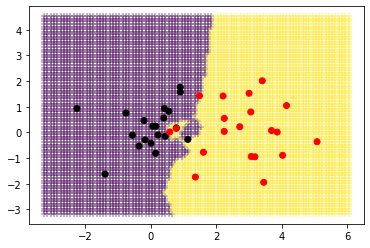

In [10]:
# decision boundary
X = pd.concat([X_train, X_test])
step = 0.1
x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

labels_pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = labels_pred.reshape(xx.shape)

plt.scatter(xx.ravel(), yy.ravel(), c=labels_pred, marker='+', alpha=0.4)
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train.replace({1:'black', 2:'red'}))
plt.show()

## The Curse of Dimensionality

The curse of dimensionality is a very important concept in machine learning. It sets a limit on the number of features to use for a given classification problem. As the dimension of the feature space increases, the classification error over an independent test set begins to increase at some point.

We'll plot the classification error as a function of dimensionality for randomly generated training and test sets. We vary the number of dimensions as follows: $d = [2, 3, 5, 10, 25, 100]$, and for each case, we generate 10 random draws from two $d$-dimensional Gaussian distributions to create training sets and test sets. Then, we average the classification results. The training set is intentionally kept small to emphasize the curse of dimensionality problem.

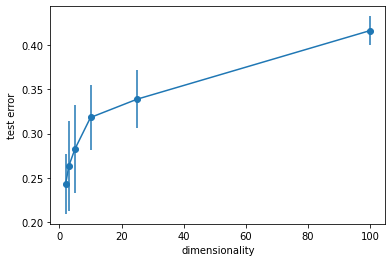

In [11]:
dimensionality = [2,3,5,10,25,100]
error_test_mean, error_test_std = [],[]

for i in dimensionality:
    error_test = [] 
    for j in range(10):
        X1 = np.random.multivariate_normal(mean=np.zeros(i),cov=np.identity(i),size=10+1000) 
        X2 = np.random.multivariate_normal(mean=np.append(2,np.zeros(i-1)),cov=np.identity(i),size=10+1000)

        X_train = np.concatenate([X1[:10,:],X2[:10,:]],axis=0)
        X_test = np.concatenate([X1[10:,:],X2[10:,:]],axis=0)
        y_train = np.repeat([1,2],10)
        y_test = np.repeat([1,2],1000)
        
        model = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
        y_pred = model.predict(X_test)
        error_test.append((y_pred!=y_test).mean())
        
    error_test_mean.append(np.mean(error_test))
    error_test_std.append(np.std(error_test))

plt.errorbar(dimensionality, error_test_mean, error_test_std)
plt.scatter(dimensionality, error_test_mean)
plt.xlabel('dimensionality')
plt.ylabel('test error')
plt.show()

## Parzen classifier

Next, let's implement the Parzen classifier from scratch for small-scale data. The function takes in a training set, training labels, a test set for which it has to predict labels, and a hyperparameter, 'h'.

In [12]:
def parzenc(X_train, y_train, X_test, h):
    classes = y_train.unique()
    priors = y_train.value_counts()[classes].values/len(y_train)
    testDistMat = distance.cdist(X_test, X_train, 'euclidean')
    g = 1/(h*np.sqrt(2*np.pi))*np.exp(-0.5*(testDistMat/h)**2)
    p = np.zeros((X_test.shape[0], len(classes)))
    
    for i in range(len(classes)):
        tmp = g[:, y_train==classes[i]]
        p[:,i] = tmp.mean(axis=1)
    
    posteriors = priors*p/((priors*p).sum(axis=1, keepdims=True))
    labels = classes[posteriors.argmax(axis=1)]
    
    return posteriors, labels

Using "boomerang2D.txt" as our dataset, we train and test the classifier for `h=0.5`? Finally, we train the classifier (with `h=0.5`) on the entire data in "boomerang2D.txt", and we visualize the decision boundary within a scatter plot of the data.

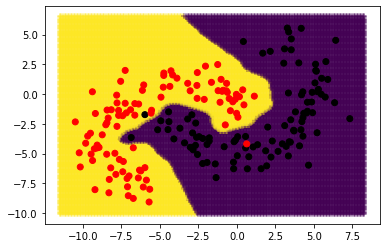

In [13]:
from sklearn.model_selection import train_test_split
from scipy.spatial import distance

path_to_file = '../data/boomerang2D.txt'
data = pd.read_csv(path_to_file, sep=' ')
X, y = data.iloc[:,:-1], data.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)

y_pred_prob, y_pred = parzenc(X_train, y_train, X_test, h=0.5)
error_test = (y_pred!=y_test).sum() 
error_test

# decision boundary 
step = 0.1
x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min,x_max,step), np.arange(y_min,y_max,step))

_ , labels_pred = parzenc(X, y, np.c_[xx.ravel(), yy.ravel()], h=0.5)    
Z = labels_pred.reshape(xx.shape)

plt.scatter(xx.ravel(), yy.ravel(), c=labels_pred, marker='+', alpha=0.4) 
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y.replace({1:'black',2:'red'}))
plt.show()